In [4]:
import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
import os 
from accuracy import compute_metrics
from generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
image_path = '/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg'
mask_path = '/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg'
image_path, mask_path


('/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg',
 '/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg')

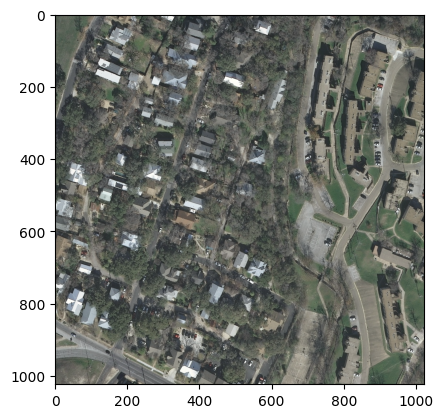

In [6]:
image = cv2.imread(image_path)
plt.imshow(image)
plt.show()

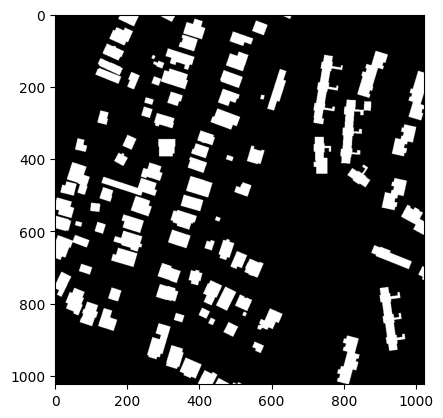

In [7]:
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
plt.imshow(mask, cmap="gray")
plt.show()

In [8]:
image.shape, mask.shape

((1024, 1024, 3), (1024, 1024))

In [6]:
## YOLO V10 - SAM

In [ ]:
yolo_model = YOLO("/home/selc-a4-sr2/Solar_Rooftop_Detection/YOLOs/yolov10/v_10best.pt")
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv10 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/yolov10_sam_predicted_mask.png")
plt.show()


In [ ]:
## YOLOv11 + SAM

In [ ]:
yolo_model = YOLO("/home/selc-a4-sr2/Solar_Rooftop_Detection/YOLOs/YOLOV_11/best.pt")
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv11 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/yolov11_sam_predicted_mask.png")
plt.show()


In [ ]:
yolo_model = YOLO("/home/selc-a4-sr2/Solar_Rooftop_Detection/YOLOs/yolov12/best.pt")
sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv12 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/yolov12_sam_predicted_mask.png")
plt.show()


In [ ]:
## DETR + SAM

In [ ]:
from rfdetr import RFDETRBase

In [ ]:
checkpoint_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/DETR/rfdetrf.pth"  
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_wrapper = RFDETRBase()
underlying_model = model_wrapper.model
underlying_model.reinitialize_detection_head(num_classes=2)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
pytorch_model = underlying_model.model
pytorch_model.load_state_dict(checkpoint['model'])

pytorch_model.to(device)
pytorch_model.eval()

sam = sam_model_registry["vit_b"]("/home/selc-a4-sr2/Solar_Rooftop_Detection/checkpoints/Final_Models/FineTune_model_3_epoch_20_03_03_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
    
detections = model_wrapper.predict(image, threshold=0.5)
boxes = detections.xyxy

# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","DETR + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/DETR_sam_predicted_mask.png")
plt.show()


In [ ]:
## UNet model

In [47]:
import torch
import cv2
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from PIL import Image

In [13]:
os.getcwd()

'/home/selc-a4-sr2/Solar_Rooftop_Detection/Solar_Rooftop_Detection'

In [14]:
os.chdir('../')
os.getcwd()

'/home/selc-a4-sr2/Solar_Rooftop_Detection'

In [48]:
from BaseLineModels.Unet_model.Unet_model import UNet

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image


In [50]:
image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg"

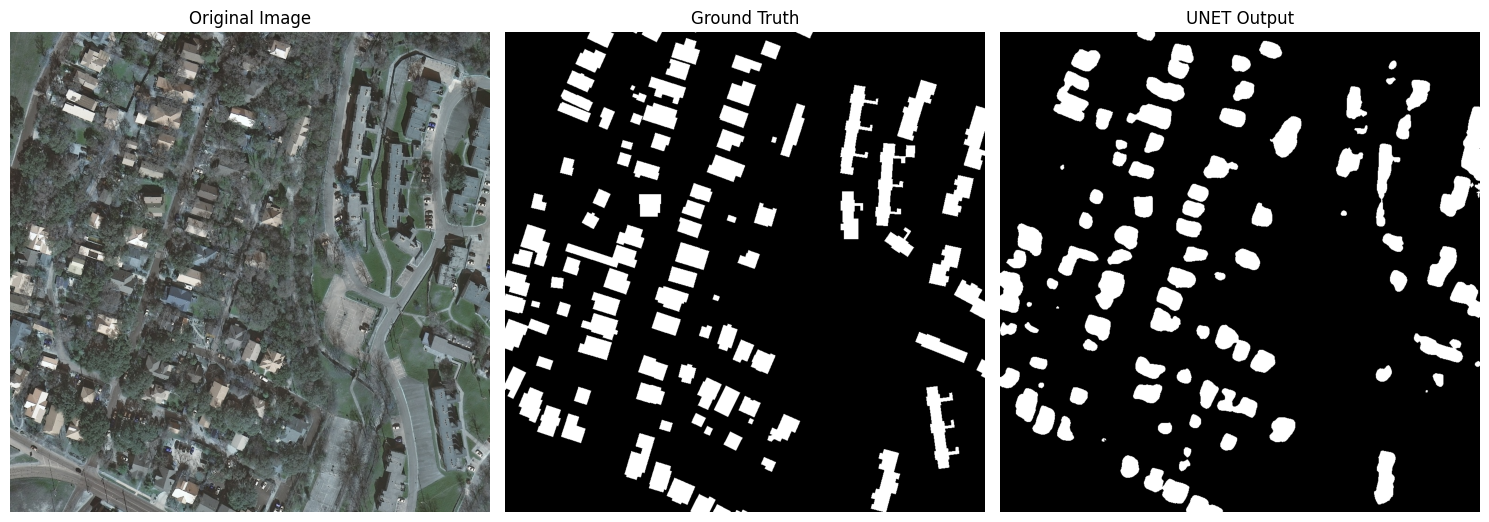

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)



my_model = UNet()
my_model.load_state_dict(torch.load("/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/Unet_model/unet_rooftop_50.pth"))
my_model.to(device=device)
my_model.eval()

with torch.no_grad():
    unet_out = my_model(image_batch)  # (1, 1, H, W)
    
    unet_mask = (unet_out > 0.5).float()

def to_numpy(t):
    return t.squeeze().detach().cpu().numpy()

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = to_numpy(mask)
pred_mask_np = to_numpy(unet_mask) 

titles = ["Original Image", "Ground Truth","UNET Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/UNET_predicted_mask.png")
plt.show()

In [52]:
## DeepLabV3

In [5]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from PIL import Image
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

In [6]:
image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg"

/tmp/ipykernel_953542/2194703605.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/deeplabv3/

(1, 1, 1024, 1024)


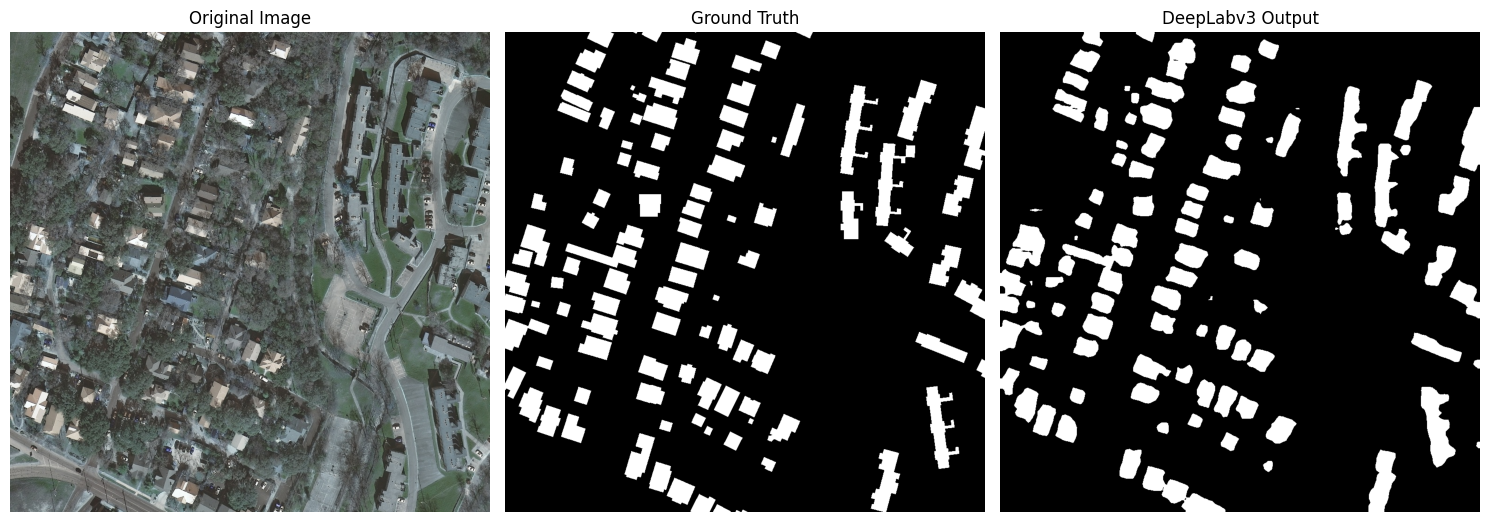

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)


model = torch.load("/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/deeplabv3/deeplab_rooftop_full_50.pth")
model.to(device)
model.eval()

with torch.no_grad():
    outputs = model(image_batch)["out"]
    preds = torch.sigmoid(outputs) > 0.5
    preds = preds.cpu().numpy().astype(np.uint8)

print(preds.shape)

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = mask.reshape(1024,1024)
pred_mask_np = preds.reshape(1024,1024)

titles = ["Original Image", "Ground Truth","DeepLabv3 Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/DEEPLABV3_predicted_mask.png")
plt.show()

In [16]:
## Mask RCNN

In [21]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
import torchvision.transforms.functional as TF
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

/tmp/ipykernel_957639/4188758059.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  my_model = torch.load(model_path)


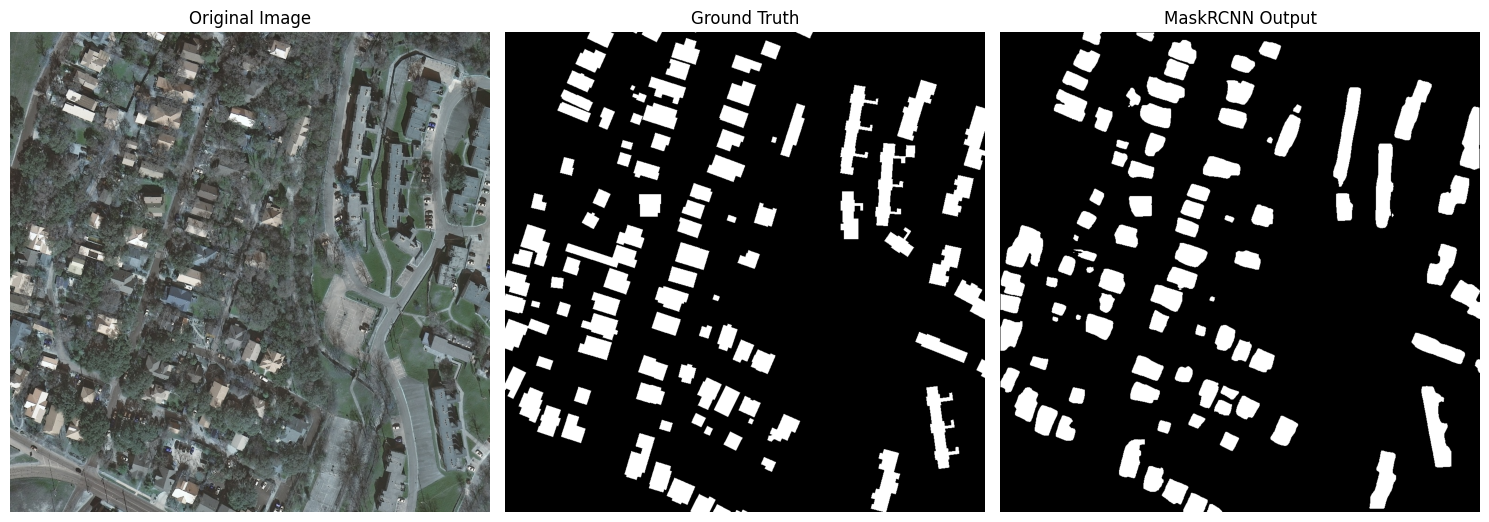

In [29]:
image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/images/42.jpg"
mask_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_validation_images/masks/42.jpg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
ground_mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)

model_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels/Maksed_RCNN/mask_rcnn_epoch_50_full.pth"
my_model = torch.load(model_path)
my_model.to(device)
my_model.eval()


with torch.no_grad():
    output = my_model(image_batch)[0]

keep = output["scores"] >= 0.5
boxes = output["boxes"][keep].cpu().numpy()
labels = output["labels"][keep].cpu().numpy()
masks = output["masks"][keep].squeeze(1).cpu().numpy()  # Shape: (N, H, W)

final_mask = torch.zeros((1024,1024), dtype=torch.float32)

for mask in masks:
    bin_mask = (mask > 0.5).astype(np.uint8)
    bin_mask_pil = TF.to_pil_image(bin_mask)
    resized_mask = TF.to_tensor(TF.resize(bin_mask_pil, (1024,1024))).squeeze(0)
    
    # Combine using logical OR
    final_mask = torch.logical_or(final_mask, resized_mask).float()
    
    
original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = ground_mask.reshape(1024,1024)
pred_mask_np = final_mask

titles = ["Original Image", "Ground Truth","MaskRCNN Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/selc-a4-sr2/Solar_Rooftop_Detection/output_images/MaskRCNN_predicted_mask.png")
plt.show()